---
title: Decoder-Only Transformer on WikiText-2
category: Deep Learning
tags:
  - deep learning
  - transformer
  - self-attention
  - language modeling
  - wikitext
  - pytorch
date: 2026-07-31
description: Build a small decoder-only Transformer for character-level language modeling on WikiText-2.
sources:
  - https://huggingface.co/datasets/Salesforce/wikitext
  - https://docs.pytorch.org/tutorials/intermediate/transformer_building_blocks.html
---

## Goal

Build a tiny decoder-only Transformer on [WikiText-2](https://huggingface.co/datasets/Salesforce/wikitext). We will use a cropped character-level corpus so the model still shows real attention behavior without turning the notebook into an hours-long training run.

Causal self-attention computes

$$
\\text{Attn}(Q, K, V) = \\text{softmax}\\left(\\frac{QK^\\top}{\\sqrt{d_k}} + M\\right)V,
$$

where the mask \(M\) is \(-\\infty\) above the diagonal so that token \(t\) cannot read from the future.


In [1]:
## %pip install -q datasets torch matplotlib einops

import math
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset


/Users/elimelt/Documents/Codex/2026-07-30/github-plugin-github-openai-curated-remote-2/work/notes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
text = "\n".join(ds["train"]["text"])[:300000]

vocab = sorted(set(text))
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for ch, i in stoi.items()}
data = torch.tensor([stoi[ch] for ch in text], dtype=torch.long)

split = int(0.9 * len(data))
train_ids = data[:split]
valid_ids = data[split:]

print(f"chars={len(data):,} vocab={len(vocab)}")


chars=300,000 vocab=154


In [3]:
def get_batch(data: torch.Tensor, batch_size: int, block_size: int, device: str):
    starts = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[s : s + block_size] for s in starts]).to(device)
    y = torch.stack([data[s + 1 : s + block_size + 1] for s in starts]).to(device)
    return x, y


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, block_size: int):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        mask = torch.tril(torch.ones(block_size, block_size))
        self.register_buffer("mask", mask.view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        scores = scores.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        attn = scores.softmax(dim=-1)
        out = attn @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(out), attn


class Block(nn.Module):
    def __init__(self, d_model: int, n_heads: int, block_size: int, mlp_mult: int = 4):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, block_size)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_mult * d_model),
            nn.GELU(),
            nn.Linear(mlp_mult * d_model, d_model),
        )

    def forward(self, x):
        attn_out, attn = self.attn(self.ln1(x))
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        return x, attn


class TinyGPT(nn.Module):
    def __init__(self, vocab_size: int, block_size: int, d_model: int = 128, n_heads: int = 4, n_layers: int = 3):
        super().__init__()
        self.block_size = block_size
        self.token = nn.Embedding(vocab_size, d_model)
        self.pos = nn.Embedding(block_size, d_model)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, block_size) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, idx):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.token(idx) + self.pos(pos)[None, :, :]
        attn_maps = []
        for block in self.blocks:
            x, attn = block(x)
            attn_maps.append(attn)
        logits = self.head(self.ln_f(x))
        return logits, attn_maps

    @torch.no_grad()
    def generate(self, idx, max_new_tokens: int):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size :]
            logits, _ = self(idx_cond)
            probs = logits[:, -1].softmax(dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_idx], dim=1)
        return idx


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
block_size = 96
model = TinyGPT(len(vocab), block_size=block_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)

losses = []
for step in range(400):
    xb, yb = get_batch(train_ids, batch_size=32, block_size=block_size, device=device)
    logits, _ = model(xb)
    loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(float(loss))

    if step % 100 == 0:
        print(f"step={step:04d} loss={float(loss):.4f}")


/var/folders/89/s5_6m3_s753b66rwdjt2g1lw0000gn/T/ipykernel_21658/2312406829.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  losses.append(float(loss))


step=0000 loss=5.2090


step=0100 loss=2.8399


step=0200 loss=2.6231


step=0300 loss=2.5646


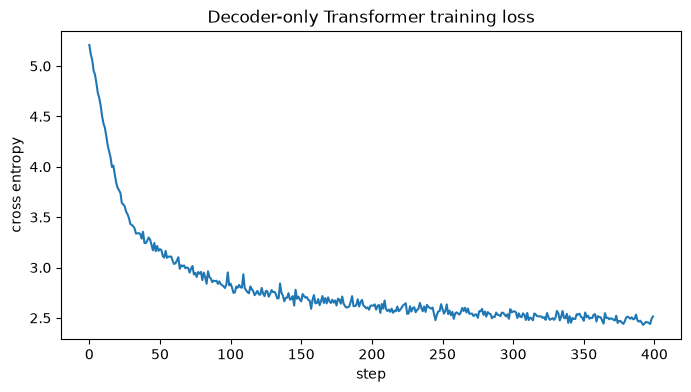

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Decoder-only Transformer training loss")
plt.xlabel("step")
plt.ylabel("cross entropy")
plt.show()


In [6]:
prompt = torch.tensor([[stoi["T"]]], dtype=torch.long, device=device)
sample = model.generate(prompt, max_new_tokens=600)[0].tolist()
print("".join(itos[i] for i in sample))


The ceg frsthegou@ f pof nd presthan ) aseinxbus aZe r ttonilァ pey tonchewh Sope d fd GNs . thacond waleter axilanghietl Secor s きathest pbore pat lerle d ds achifinghat . pone . inia , sinee ped tho bithessin ebek on tan pHiove emsese th 100 ć 11 s ; omof s ced t Gathean Rhe his~o A c/ ben Thaid " atod Hed This iuro saleciechythe therand pesud aana ermug . obes acaste rens . Ked ess Crme ind tam rofo Hawens ds , aKinof . th acamed d . , y The trand " cndzeate tthe , ind , jt , thangfons . @ 'se Jentas ckeare 2 . . , the wro Hede tang opan ses g 
 cere 'sin Hedal Hengrllefolapo. ous layechiov0 


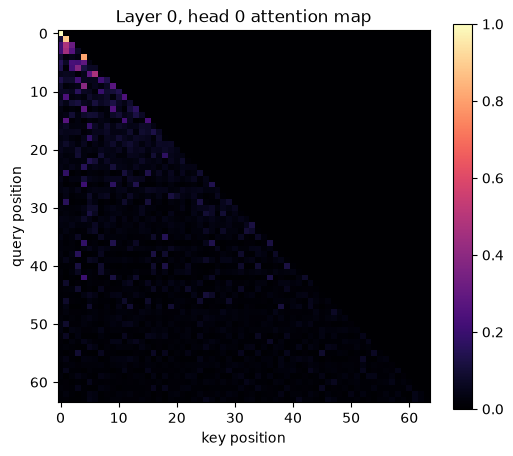

In [7]:
xb, _ = get_batch(valid_ids, batch_size=1, block_size=64, device=device)
_, attn_maps = model(xb)
head0 = attn_maps[0][0, 0].detach().cpu()

plt.figure(figsize=(6, 5))
plt.imshow(head0, cmap="magma")
plt.title("Layer 0, head 0 attention map")
plt.xlabel("key position")
plt.ylabel("query position")
plt.colorbar()
plt.show()


## Why This Notebook Matters

A character-level model is toy-sized, but the mechanics are real. The same masking rule, residual shape discipline, and next-token objective scale up to practical decoder-only language models.
